# Supplementary Figure: ETresid_ETsimul precipitation respons

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [ ]:
working_dir = Path.cwd().resolve()
repository_root = next(
    parent
    for parent in (working_dir, *working_dir.parents)
    if (parent / '08_figures' / 'main_figures' / 'figure_1' / 'local' / 'data').is_dir()
)

APPENDIX_DIR = repository_root / '08_figures' / 'appendix' / 'figure_1_ETresid_ETsimul'
NEW_DATA_DIR = APPENDIX_DIR / 'local' / 'data'
FIGURE_1_DATA_DIR = repository_root / '08_figures' / 'main_figures' / 'figure_1' / 'local' / 'data'
PLOT_DIR = APPENDIX_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

TIME_SERIES_FILE = NEW_DATA_DIR / 'precipitation_time_series_ETresid_ETsimul.csv'
PERIOD_MEANS_FILE = NEW_DATA_DIR / 'period_means_ETresid_ETsimul.nc'
AMAZON_MASK_FILE = repository_root / '01_climate_data' / '01_c_NorESM2' / 'amazon_mask' / 'amazon_mask.tif'

PERIODS = ('2030-2044', '2050-2069', '2080-2099')
DEFORESTATION_FILES = {
    period: FIGURE_1_DATA_DIR / f'binary_defors_map_{period.replace(chr(45), chr(95))}.nc'
    for period in PERIODS
}

required_files = [TIME_SERIES_FILE, PERIOD_MEANS_FILE, AMAZON_MASK_FILE, *DEFORESTATION_FILES.values()]
missing_files = [str(path) for path in required_files if not path.is_file()]
if missing_files:
    raise FileNotFoundError('Missing required local file(s):\\n' + '\\n'.join(missing_files))

print(f'ETresid_ETsimul data: {NEW_DATA_DIR}')
print(f'Figure 1 shared data: {FIGURE_1_DATA_DIR}')


ETresid_ETsimul data: C:\Users\Clemens\Desktop\amazon_code_public\08_figures\appendix\figure_1_ETresid_ETsimul\local\data
Figure 1 shared data: C:\Users\Clemens\Desktop\amazon_code_public\08_figures\main_figures\figure_1\local\data


In [ ]:
# Load the two ETresid_ETsimul results and the shared Figure 1 map inputs.
time_series = pd.read_csv(TIME_SERIES_FILE)
period_means = xr.open_dataset(PERIOD_MEANS_FILE)

deforestation_maps = {
    period: xr.open_dataset(path)['deforestation']
    for period, path in DEFORESTATION_FILES.items()
}
deforestation_lon = deforestation_maps[PERIODS[0]].longitude.values
deforestation_lat = deforestation_maps[PERIODS[0]].latitude.values
deforestation_lon2d, deforestation_lat2d = np.meshgrid(deforestation_lon, deforestation_lat)

# Exact Amazon boundary from the original raster pixels
with rasterio.open(AMAZON_MASK_FILE) as source:
    mask_values = source.read(1)
    mask_transform = source.transform

mask_domain = np.isfinite(mask_values)
mask_polygons = [
    shape(geometry)
    for geometry, value in shapes(
        mask_domain.astype(np.uint8), mask=mask_domain, transform=mask_transform
    )
    if value == 1
]
amazon_outline = max(mask_polygons, key=lambda polygon: polygon.area)

all_values = np.concatenate([period_means[period].values.ravel() for period in PERIODS])
all_values = all_values[np.isfinite(all_values)]
limit = float(np.nanmax(np.abs(all_values)))
change_norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

lon = period_means[PERIODS[0]].longitude.values
lat = period_means[PERIODS[0]].latitude.values
lon2d, lat2d = np.meshgrid(lon, lat)
print(f'Symmetric map scale: +/- {limit:.2f}%')


Symmetric map scale: +/- 57.83%


C:\Users\Clemens\AppData\Local\Temp\ipykernel_19084\1581640008.py:15: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  mask_values = source.read(1)


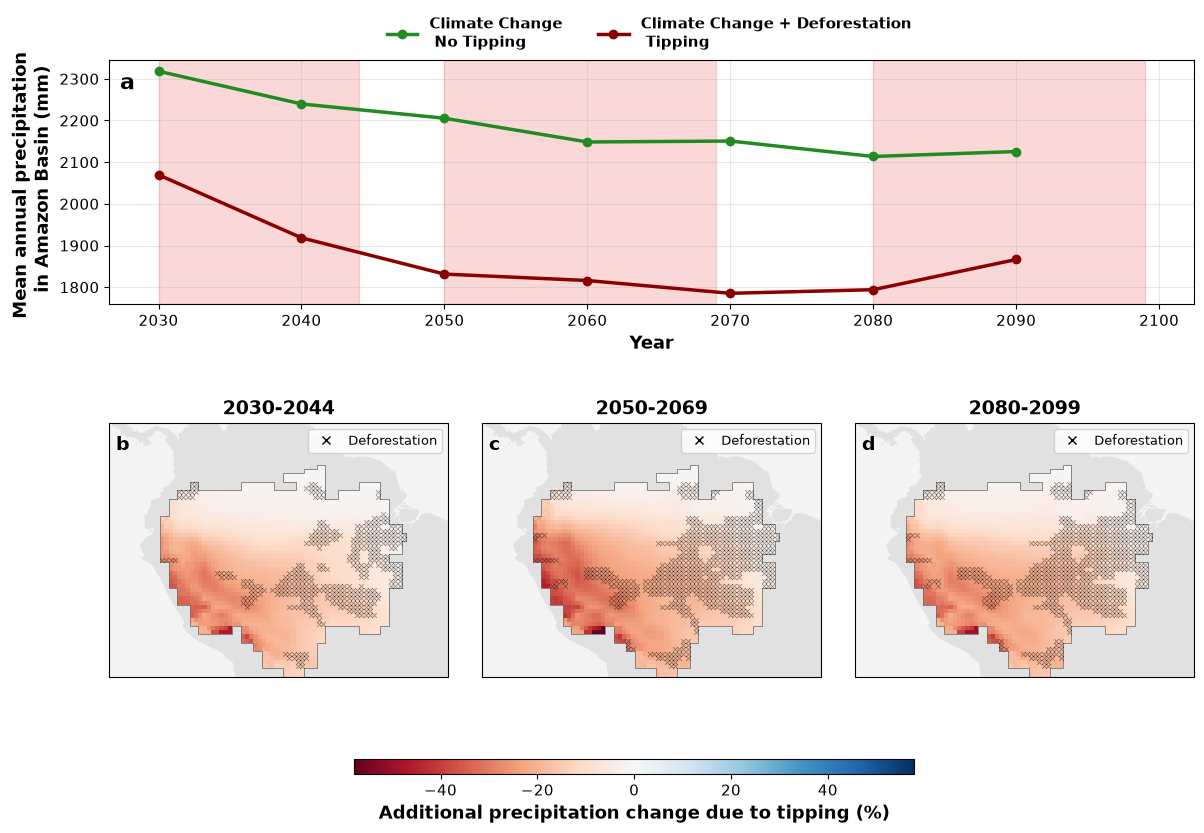

Saved: C:\Users\Clemens\Desktop\amazon_code_public\08_figures\appendix\figure_1_ETresid_ETsimul\plots\ETresid_ETsimul_precipitation_time_series_and_maps.png


In [4]:
# Local Figure 1-style supplementary plot: time series plus three precipitation-change maps.
data_crs = ccrs.PlateCarree()
bbox = dict(lon_min=-85, lon_max=-45, lat_min=-20, lat_max=10)

fig = plt.figure(figsize=(14, 8.5))
grid = GridSpec(2, 3, height_ratios=[1.0, 1.35], hspace=0.28, wspace=0.10)

ax_ts = fig.add_subplot(grid[0, :])
for start_year, end_year in ((2030, 2044), (2050, 2069), (2080, 2099)):
    ax_ts.axvspan(start_year, end_year, color='lightcoral', alpha=0.30, zorder=0)

ax_ts.plot(
    time_series['time'], time_series['ts_no_tip'],
    label='Climate Change \n No Tipping', marker='o', color='forestgreen', linewidth=2.5
)
ax_ts.plot(
    time_series['time'], time_series['ts_tip'],
    label='Climate Change + Deforestation \n Tipping', marker='o', color='darkred', linewidth=2.5
)
ax_ts.grid(alpha=0.30)
ax_ts.set_ylabel('Mean annual precipitation \n in Amazon Basin (mm)', fontsize=13, fontweight='bold')
ax_ts.set_xlabel('Year', fontsize=13, fontweight='bold')
ax_ts.tick_params(axis='both', labelsize=11)
legend = ax_ts.legend(loc='upper center', bbox_to_anchor=(0.5, 1.24), ncol=2, frameon=False, fontsize=11)
for text in legend.get_texts():
    text.set_fontweight('bold')
ax_ts.text(0.01, 0.95, 'a', transform=ax_ts.transAxes, fontsize=16, fontweight='bold', va='top')

for index, period in enumerate(PERIODS):
    ax = fig.add_subplot(grid[1, index], projection=data_crs)
    ax.set_facecolor('#F4F4F4')
    ax.add_feature(cfeature.OCEAN, facecolor='#F4F4F4', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='#E1E1E1', zorder=1)

    image = ax.pcolormesh(
        lon2d, lat2d, period_means[period].values,
        shading='auto', cmap='RdBu', norm=change_norm,
        transform=data_crs, zorder=2
    )
    outline_x, outline_y = amazon_outline.exterior.xy
    ax.plot(
        outline_x, outline_y, color='#6B6B6B', linewidth=0.55,
        solid_capstyle='butt', solid_joinstyle='miter',
        transform=data_crs, zorder=4
    )

    deforested = deforestation_maps[period].values == 1
    ax.scatter(
        deforestation_lon2d[deforested], deforestation_lat2d[deforested],
        s=12, marker='x', linewidths=0.6, color='black', alpha=0.4,
        transform=data_crs, zorder=5
    )
    ax.set_extent([bbox['lon_min'], bbox['lon_max'], bbox['lat_min'], bbox['lat_max']], crs=data_crs)
    ax.tick_params(labelsize=10)
    if index != 0:
        ax.set_yticks([])
    ax.set_title(period, fontsize=14, fontweight='bold')
    ax.text(0.02, 0.95, chr(ord('b') + index), transform=ax.transAxes, fontsize=14, fontweight='bold', va='top')

    deforestation_handle = Line2D(
        [], [], marker='x', linestyle='None', markersize=6,
        markeredgewidth=1.0, color='black', label='Deforestation'
    )
    ax.legend(handles=[deforestation_handle], loc='upper right', frameon=True, framealpha=0.8, fontsize=9)

colorbar_axis = fig.add_axes([0.30, 0.04, 0.40, 0.018])
colorbar = fig.colorbar(image, cax=colorbar_axis, orientation='horizontal')
colorbar.ax.tick_params(labelsize=11)
colorbar.set_label('Additional precipitation change due to tipping (%)', fontsize=13, fontweight='bold')

plot_file = PLOT_DIR / 'ETresid_ETsimul_precipitation_time_series_and_maps.png'
fig.savefig(plot_file, dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()
print(f'Saved: {plot_file}')
